# Yellow Taxi adat

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [3]:
testYellow = Path('raw_data/2009/yellow_tripdata_2009-01.parquet')

In [4]:
if not testYellow.exists():
    raise FileNotFoundError(f'Not found: {testYellow.resolve()}')

trips_df = pd.read_parquet(testYellow)

print(f'Rows: {len(trips_df):,}')
print(f'Columns: {trips_df.shape[1]}')
trips_df.head()

Rows: 14,092,412
Columns: 8


,pickup_at,dropoff_at,passenger_count,trip_distance,pickup_lon,pickup_lat,dropoff_lon,dropoff_lat
0,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,-73.993803,40.695922
1,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,-73.955850,40.768030
2,2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,-74.002587,40.739748,-73.869983,40.770225
3,2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.00,-73.974267,40.790955,-73.996558,40.731849
4,2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.40,-74.001580,40.719382,-74.008378,40.720350


## Info

In [5]:
trips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14092412 entries, 0 to 14092411
Data columns (total 8 columns):
 #   Column           Dtype         
---  ------           -----         
 0   pickup_at        datetime64[us]
 1   dropoff_at       datetime64[us]
 2   passenger_count  int64         
 3   trip_distance    float64       
 4   pickup_lon       float64       
 5   pickup_lat       float64       
 6   dropoff_lon      float64       
 7   dropoff_lat      float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 860.1 MB


## Compute Missing Value Ratio

In [8]:
# Percentage of missing values per column
missing_pct = trips_df.isna().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)

display(missing_pct.to_frame(name="missing_pct"))

,missing_pct
mta_tax,100.000000
Rate_Code,100.000000
store_and_forward,99.991314
vendor_name,0.000000
Trip_Pickup_DateTime,0.000000
Trip_Dropoff_DateTime,0.000000
Start_Lon,0.000000
Trip_Distance,0.000000
Start_Lat,0.000000
Passenger_Count,0.000000


## Drop Columns Above Threshold

In [9]:
missing_threshold = 40  # percentage

cols_to_drop = missing_pct[missing_pct > missing_threshold].index

print(f"Columns above {missing_threshold}% missing values:")
print(list(cols_to_drop))

trips_df = trips_df.drop(columns=cols_to_drop)

print(f"\nRemaining columns: {trips_df.shape[1]}")

Columns above 40% missing values:
['mta_tax', 'Rate_Code', 'store_and_forward']

Remaining columns: 15


## Check duplicate rows

In [10]:
dup_rows = trips_df.duplicated().sum()
print(f'Duplicate rows: {dup_rows:,}')

Duplicate rows: 31


## Remove duplicate rows

In [11]:
trips_df = trips_df.drop_duplicates()

dup_rows_after = trips_df.duplicated().sum()
print(f'Duplicate rows after cleaning: {dup_rows_after}')

Duplicate rows after cleaning: 0


## Data columns

In [12]:
trips_df.dtypes

vendor_name                  str
Trip_Pickup_DateTime         str
Trip_Dropoff_DateTime        str
Passenger_Count            int64
Trip_Distance            float64
Start_Lon                float64
Start_Lat                float64
End_Lon                  float64
End_Lat                  float64
Payment_Type                 str
Fare_Amt                 float64
surcharge                float64
Tip_Amt                  float64
Tolls_Amt                float64
Total_Amt                float64
dtype: object

## Canonical schema

In [13]:
# Columns we want to keep from the raw yellow taxi dataset
columns_to_keep = [
    'vendor_name',
    'Trip_Pickup_DateTime',
    'Trip_Dropoff_DateTime',
    'Passenger_Count',
    'Trip_Distance',
    'Start_Lon',
    'Start_Lat',
    'End_Lon',
    'End_Lat',
]

trips_df = trips_df[columns_to_keep].copy()

rename_map = {
    'vendor_name': 'vendor_id',
    'Trip_Pickup_DateTime': 'pickup_at',
    'Trip_Dropoff_DateTime': 'dropoff_at',
    'Passenger_Count': 'passenger_count',
    'Trip_Distance': 'trip_distance',
    'Start_Lon': 'pickup_lon',
    'Start_Lat': 'pickup_lat',
    'End_Lon': 'dropoff_lon',
    'End_Lat': 'dropoff_lat',
}

trips_df = trips_df.rename(columns=rename_map)

for c in ['pickup_at', 'dropoff_at']:
    if c in trips_df.columns:
        trips_df[c] = pd.to_datetime(trips_df[c], errors='coerce')

trips_df.info()

<class 'pandas.DataFrame'>
Index: 14092382 entries, 0 to 14092412
Data columns (total 9 columns):
 #   Column           Dtype         
---  ------           -----         
 0   vendor_id        str           
 1   pickup_at        datetime64[us]
 2   dropoff_at       datetime64[us]
 3   passenger_count  int64         
 4   trip_distance    float64       
 5   pickup_lon       float64       
 6   pickup_lat       float64       
 7   dropoff_lon      float64       
 8   dropoff_lat      float64       
dtypes: datetime64[us](2), float64(5), int64(1), str(1)
memory usage: 1.1 GB


## Typing

In [14]:
roles = {'datetime': [], 'categorical': [], 'discrete': [], 'continuous': []}

for col in trips_df.columns:
    s = trips_df[col]

    if pd.api.types.is_datetime64_any_dtype(s):
        roles['datetime'].append(col)
        continue

    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s) or pd.api.types.is_bool_dtype(s):
        roles['categorical'].append(col)
        continue

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        unique_n = non_null.nunique()

        is_int_like = pd.api.types.is_integer_dtype(s)
        if (not is_int_like) and len(non_null) > 0:
            sample = non_null.iloc[:50_000]
            is_int_like = np.all(np.isclose(sample.to_numpy(), np.round(sample.to_numpy())))

        if is_int_like and unique_n <= 200:
            roles['discrete'].append(col)
        else:
            roles['continuous'].append(col)
        continue

    roles['categorical'].append(col)

for role_name, cols in roles.items():
    print(f'{role_name}: {len(cols)} column')
    print(cols)


datetime: 2 column
['pickup_at', 'dropoff_at']
categorical: 1 column
['vendor_id']
discrete: 1 column
['passenger_count']
continuous: 5 column
['trip_distance', 'pickup_lon', 'pickup_lat', 'dropoff_lon', 'dropoff_lat']


## Exploratory Data Analysis visualization


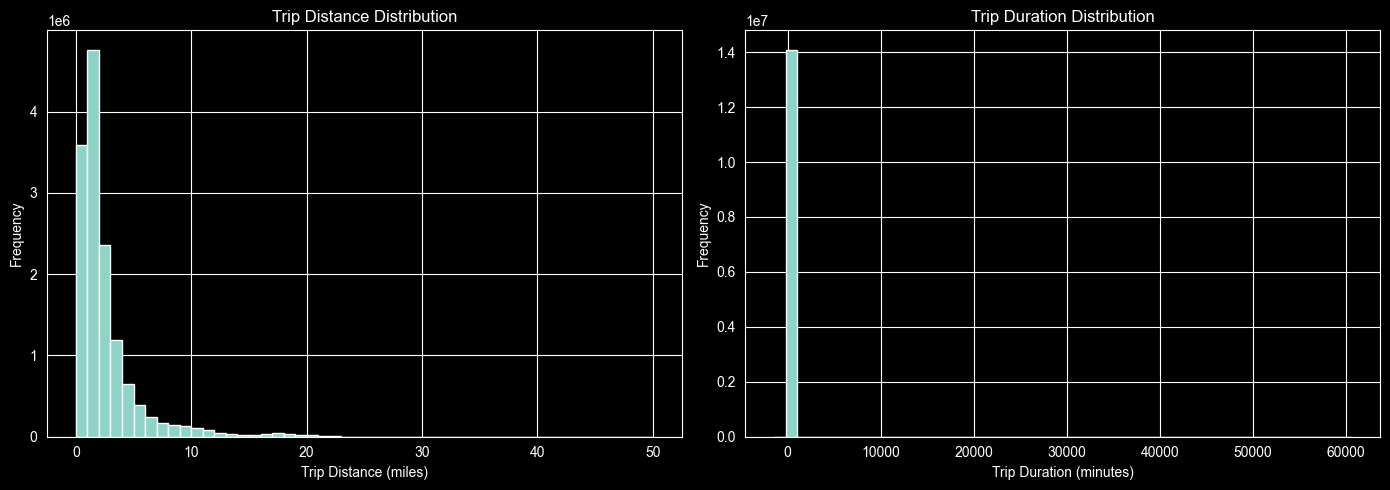

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trip distance distribution
if 'trip_distance' in trips_df.columns:
    trips_df['trip_distance'].hist(bins=50, ax=axes[0])
    axes[0].set_title("Trip Distance Distribution")
    axes[0].set_xlabel("Trip Distance (miles)")
    axes[0].set_ylabel("Frequency")

# Trip duration distribution
if {'pickup_at', 'dropoff_at'}.issubset(trips_df.columns):
    duration = (trips_df['dropoff_at'] - trips_df['pickup_at']).dt.total_seconds() / 60.0
    duration.hist(bins=50, ax=axes[1])
    axes[1].set_title("Trip Duration Distribution")
    axes[1].set_xlabel("Trip Duration (minutes)")
    axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Simple clean

In [16]:
clean_df = trips_df.copy()
initial_rows = len(clean_df)

if {'pickup_at', 'dropoff_at'}.issubset(clean_df.columns):
    clean_df = clean_df[
        clean_df['pickup_at'].notna()
        & clean_df['dropoff_at'].notna()
        & (clean_df['dropoff_at'] >= clean_df['pickup_at'])
        ]

if 'passenger_count' in clean_df.columns:
    clean_df = clean_df[clean_df['passenger_count'].between(1, 8)]

if 'trip_distance' in clean_df.columns:
    distance_outlier_mask = ~clean_df['trip_distance'].between(0, 200)
    distance_outlier_rows = distance_outlier_mask.sum()

    print(f"\nTrip distance outliers: {distance_outlier_rows:,}")

    if distance_outlier_rows > 0:
        display(clean_df.loc[distance_outlier_mask, ['trip_distance']].head(10))

    clean_df = clean_df.loc[~distance_outlier_mask].copy()
    print(f"Cleaned rows after distance cleaning: {initial_rows - len(clean_df):,}")

if {'pickup_at', 'dropoff_at'}.issubset(clean_df.columns):
    clean_df['trip_duration_min'] = (
            (clean_df['dropoff_at'] - clean_df['pickup_at']).dt.total_seconds() / 60.0
    )

    duration_outlier_mask = ~clean_df['trip_duration_min'].between(1, 300)
    duration_outlier_rows = duration_outlier_mask.sum()

    print(f"\nTrip duration outliers: {duration_outlier_rows:,}")

    if duration_outlier_rows > 0:
        display(
            clean_df.loc[
                duration_outlier_mask,
                ['pickup_at', 'dropoff_at', 'trip_duration_min', 'trip_distance']
            ].head(10)
        )

    clean_df = clean_df.loc[~duration_outlier_mask].copy()
    print(f"Cleaned rows after duration cleaning: {initial_rows - len(clean_df):,}")

if 'pickup_at' in clean_df.columns:
    clean_df['pickup_hour'] = clean_df['pickup_at'].dt.hour
    clean_df['pickup_weekday'] = clean_df['pickup_at'].dt.weekday

print(f"Initial rows: {initial_rows:,}")
print(f"Final rows:   {len(clean_df):,}")
clean_df.head()


Trip distance outliers: 0
Cleaned rows after distance cleaning: 175,798

Trip duration outliers: 168,595


,pickup_at,dropoff_at,trip_duration_min,trip_distance
24,2009-01-03 01:34:33,2009-01-03 01:35:10,0.616667,0.10
83,2009-01-06 16:52:38,2009-01-06 16:53:05,0.450000,0.00
147,2009-01-26 16:32:00,2009-01-26 16:32:00,0.000000,0.99
276,2009-01-23 19:57:00,2009-01-23 19:57:00,0.000000,1.35
288,2009-01-12 21:27:00,2009-01-12 21:27:00,0.000000,0.77
325,2009-01-24 11:16:00,2009-01-24 11:16:00,0.000000,0.00
327,2009-01-23 23:21:00,2009-01-23 23:21:00,0.000000,0.67
332,2009-01-24 00:00:00,2009-01-24 23:55:00,1435.000000,1.26
338,2009-01-11 12:52:00,2009-01-11 12:52:00,0.000000,1.48
359,2009-01-21 18:45:00,2009-01-21 18:45:00,0.000000,0.49


Cleaned rows after duration cleaning: 344,393
Initial rows: 14,092,382
Final rows:   13,747,989


,vendor_id,pickup_at,dropoff_at,passenger_count,trip_distance,pickup_lon,pickup_lat,dropoff_lon,dropoff_lat,trip_duration_min,pickup_hour,pickup_weekday
0,VTS,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,-73.993803,40.695922,10.000000,2,6
1,VTS,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,-73.955850,40.768030,7.000000,3,6
2,VTS,2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,-74.002587,40.739748,-73.869983,40.770225,14.000000,15,5
3,DDS,2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.00,-73.974267,40.790955,-73.996558,40.731849,21.033333,20,3
4,DDS,2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.40,-74.001580,40.719382,-74.008378,40.720350,6.550000,16,5


### EDA after cleaning

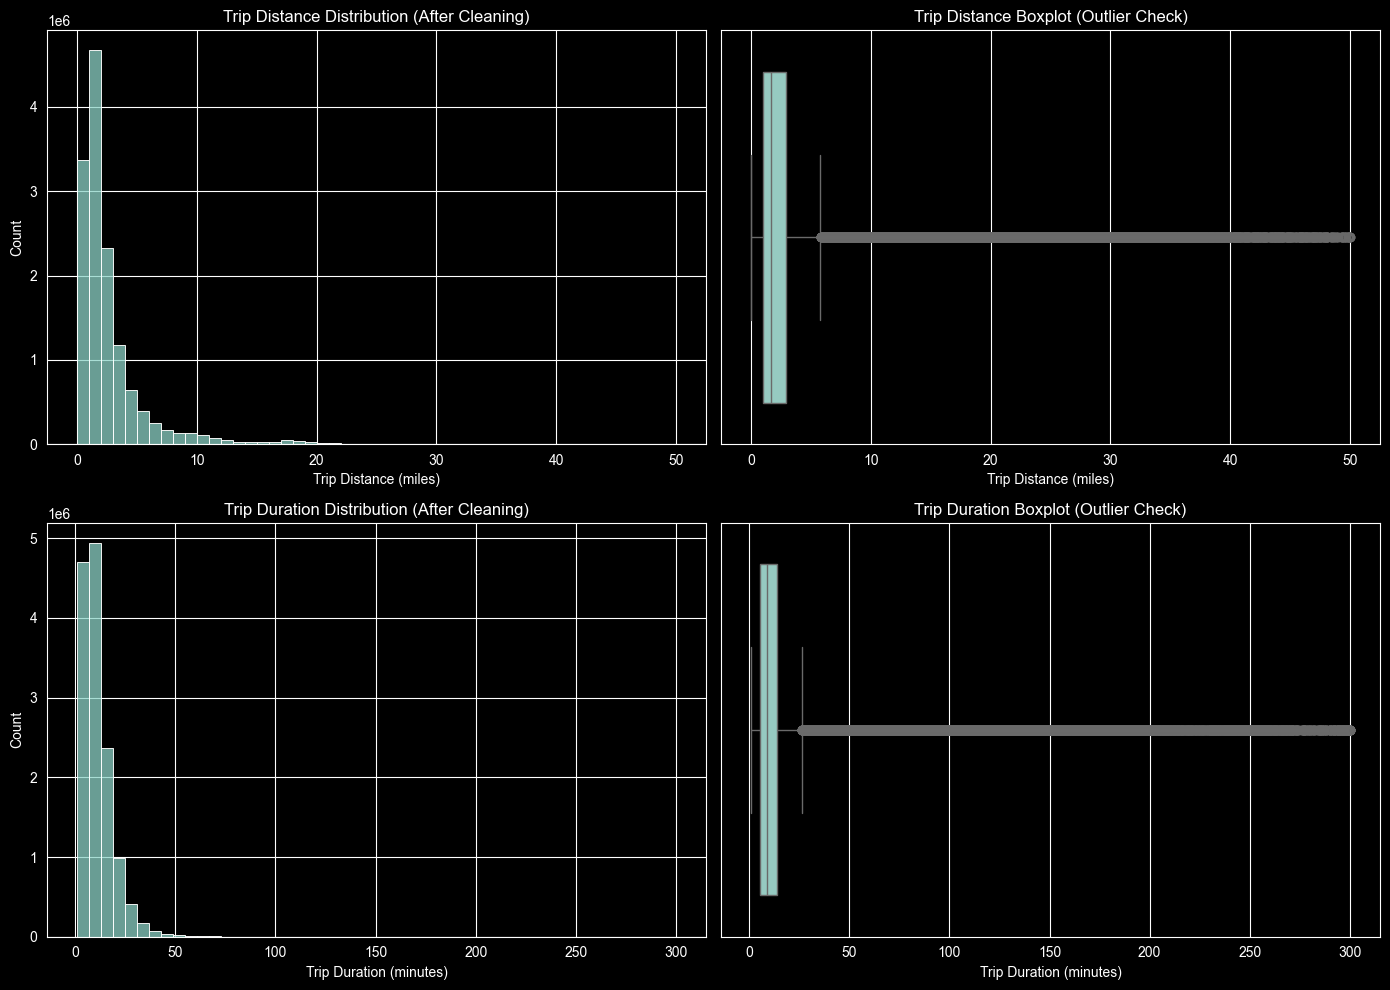

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trip distance histogram
sns.histplot(clean_df['trip_distance'], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Trip Distance Distribution (After Cleaning)")
axes[0, 0].set_xlabel("Trip Distance (miles)")

# Trip distance boxplot
sns.boxplot(x=clean_df['trip_distance'], ax=axes[0, 1])
axes[0, 1].set_title("Trip Distance Boxplot (Outlier Check)")
axes[0, 1].set_xlabel("Trip Distance (miles)")

# Trip duration histogram
sns.histplot(clean_df['trip_duration_min'], bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Trip Duration Distribution (After Cleaning)")
axes[1, 0].set_xlabel("Trip Duration (minutes)")

# Trip duration boxplot
sns.boxplot(x=clean_df['trip_duration_min'], ax=axes[1, 1])
axes[1, 1].set_title("Trip Duration Boxplot (Outlier Check)")
axes[1, 1].set_xlabel("Trip Duration (minutes)")

plt.tight_layout()
plt.show()

## Final data

In [18]:
final_df = clean_df.copy()

final_df.info()

final_df.head()

<class 'pandas.DataFrame'>
Index: 13747989 entries, 0 to 14092412
Data columns (total 12 columns):
 #   Column             Dtype         
---  ------             -----         
 0   vendor_id          str           
 1   pickup_at          datetime64[us]
 2   dropoff_at         datetime64[us]
 3   passenger_count    int64         
 4   trip_distance      float64       
 5   pickup_lon         float64       
 6   pickup_lat         float64       
 7   dropoff_lon        float64       
 8   dropoff_lat        float64       
 9   trip_duration_min  float64       
 10  pickup_hour        int32         
 11  pickup_weekday     int32         
dtypes: datetime64[us](2), float64(6), int32(2), int64(1), str(1)
memory usage: 1.3 GB


,vendor_id,pickup_at,dropoff_at,passenger_count,trip_distance,pickup_lon,pickup_lat,dropoff_lon,dropoff_lat,trip_duration_min,pickup_hour,pickup_weekday
0,VTS,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,-73.993803,40.695922,10.000000,2,6
1,VTS,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,-73.955850,40.768030,7.000000,3,6
2,VTS,2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,-74.002587,40.739748,-73.869983,40.770225,14.000000,15,5
3,DDS,2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.00,-73.974267,40.790955,-73.996558,40.731849,21.033333,20,3
4,DDS,2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.40,-74.001580,40.719382,-74.008378,40.720350,6.550000,16,5


<Axes: >

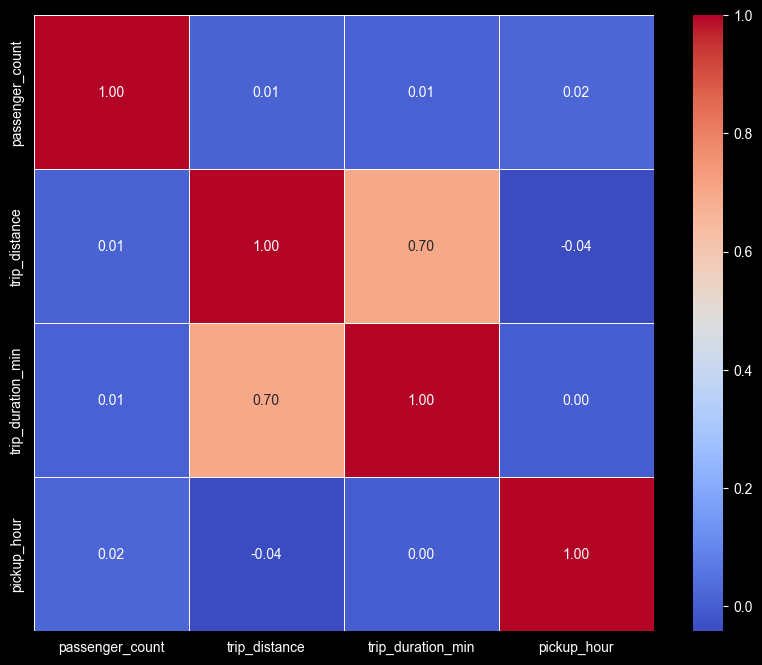

In [22]:
correlation_matrix = final_df[['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)